# ENTRENANDO MODELO DE ML PARA PREDECIR PRECIO DE AUTO USADO EN PERÚ
## DATASET: NEOAUTO

# PASO 1 - INSTALAMOS E IMPORTAMOS LIBRERIAS

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set(style='whitegrid',context='notebook')

# PASO 2 CARGAMOS EL DATASET

In [8]:
df = pd.read_csv('/content/autos_clean.csv')
df

,fuel,location,price,year,subcategory,transmission
0,gasolina,lima,10900.0,2021,otros,mecanica
1,gasolina,lima,30990.0,2020,camioneta,secuencial
2,gasolina,lima,19900.0,2020,camioneta,automatica
3,gasolina,lima,279000.0,2022,deportivo,secuencial
4,gasolina,lima,13900.0,2017,camioneta,secuencial
...,...,...,...,...,...,...
3896,gasolina,lima,11000.0,2015,otros,automatica
3897,gasolina,lima,10000.0,2018,camioneta,secuencial
3898,gasolina,lima,18500.0,2024,camioneta,automatica
3899,gasolina,provincia,13700.0,2016,otros,automatica


## PASO 3 - PREPROCESAMIENTO DE VARIABLES NÚMERICAS

In [9]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [10]:
df_cleaned = remove_outliers(df,'price')
df_cleaned

,fuel,location,price,year,subcategory,transmission
0,gasolina,lima,10900.0,2021,otros,mecanica
1,gasolina,lima,30990.0,2020,camioneta,secuencial
2,gasolina,lima,19900.0,2020,camioneta,automatica
4,gasolina,lima,13900.0,2017,camioneta,secuencial
6,gasolina,lima,15900.0,2018,camioneta,automatica
...,...,...,...,...,...,...
3896,gasolina,lima,11000.0,2015,otros,automatica
3897,gasolina,lima,10000.0,2018,camioneta,secuencial
3898,gasolina,lima,18500.0,2024,camioneta,automatica
3899,gasolina,provincia,13700.0,2016,otros,automatica


In [11]:
df_cleaned = remove_outliers(df_cleaned,'year')
df_cleaned

,fuel,location,price,year,subcategory,transmission
0,gasolina,lima,10900.0,2021,otros,mecanica
1,gasolina,lima,30990.0,2020,camioneta,secuencial
2,gasolina,lima,19900.0,2020,camioneta,automatica
4,gasolina,lima,13900.0,2017,camioneta,secuencial
6,gasolina,lima,15900.0,2018,camioneta,automatica
...,...,...,...,...,...,...
3896,gasolina,lima,11000.0,2015,otros,automatica
3897,gasolina,lima,10000.0,2018,camioneta,secuencial
3898,gasolina,lima,18500.0,2024,camioneta,automatica
3899,gasolina,provincia,13700.0,2016,otros,automatica


# PASO 4: CODIFICACIÓN DE VARIABLES CATEGORICAS CON SKLEARN

## 4.1 IDENTIFICAMOS VARIABLES CATEGORICAS

In [12]:
categorical_columns = df.select_dtypes(object).columns
categorical_columns

Index(['fuel', 'location', 'subcategory', 'transmission'], dtype='object')

## 4.2 CREAMOS LISTA POR TIPO DE CODIFICACIÓN

In [13]:
for cc in categorical_columns:
  print("*"*50)
  print(df[cc].value_counts())

**************************************************
fuel
gasolina    2919
otro         982
Name: count, dtype: int64
**************************************************
location
lima         3489
provincia     412
Name: count, dtype: int64
**************************************************
subcategory
camioneta    2293
otros        1477
deportivo     131
Name: count, dtype: int64
**************************************************
transmission
secuencial    1595
automatica    1277
mecanica      1029
Name: count, dtype: int64


## 4.3 DIVIDO LAS VARIABLES POR TIOP DE CODIFICACIÓN(LABEL Y ONE HOT ENCODING)

In [14]:
ordinal_cols = ['fuel','subcategory','transmission']
onehot_cols = list(set(categorical_columns) - set(ordinal_cols))
print(ordinal_cols,onehot_cols)

['fuel', 'subcategory', 'transmission'] ['location']


## 4.4 CODIFICAMOS USANDO LOS MODULSO COMPOSE Y PREPROCESSING DE SKLEARN

In [15]:
import sklearn.compose
import sklearn.preprocessing

### 4.4.1 CREAMOS UN TRANSFORMER

In [16]:
transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OrdinalEncoder(),ordinal_cols),
    (sklearn.preprocessing.OneHotEncoder(),onehot_cols),
    remainder='passthrough'
)
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('ordinalencoder', OrdinalEncoder(),
                                 ['fuel', 'subcategory', 'transmission']),
                                ('onehotencoder', OneHotEncoder(),
                                 ['location'])])

### 4.4.2 APLICAMOS EL TRANSFOMER A EL DATASET

In [17]:
data_transformed_df = (
    pd.DataFrame(
        transformer.fit_transform(df),
        columns = transformer.get_feature_names_out(),
        index=df.index
    )
)
data_transformed_df

,ordinalencoder__fuel,ordinalencoder__subcategory,ordinalencoder__transmission,onehotencoder__location_lima,onehotencoder__location_provincia,remainder__price,remainder__year
0,0.0,2.0,1.0,1.0,0.0,10900.0,2021.0
1,0.0,0.0,2.0,1.0,0.0,30990.0,2020.0
2,0.0,0.0,0.0,1.0,0.0,19900.0,2020.0
3,0.0,1.0,2.0,1.0,0.0,279000.0,2022.0
4,0.0,0.0,2.0,1.0,0.0,13900.0,2017.0
...,...,...,...,...,...,...,...
3896,0.0,2.0,0.0,1.0,0.0,11000.0,2015.0
3897,0.0,0.0,2.0,1.0,0.0,10000.0,2018.0
3898,0.0,0.0,0.0,1.0,0.0,18500.0,2024.0
3899,0.0,2.0,0.0,0.0,1.0,13700.0,2016.0


In [18]:
data_transformed_df = data_transformed_df.rename(
    columns=lambda x: x.replace("ordinalencoder__", "").replace("onehotencoder__", "").replace("remainder__", "")
)

data_transformed_df

,fuel,subcategory,transmission,location_lima,location_provincia,price,year
0,0.0,2.0,1.0,1.0,0.0,10900.0,2021.0
1,0.0,0.0,2.0,1.0,0.0,30990.0,2020.0
2,0.0,0.0,0.0,1.0,0.0,19900.0,2020.0
3,0.0,1.0,2.0,1.0,0.0,279000.0,2022.0
4,0.0,0.0,2.0,1.0,0.0,13900.0,2017.0
...,...,...,...,...,...,...,...
3896,0.0,2.0,0.0,1.0,0.0,11000.0,2015.0
3897,0.0,0.0,2.0,1.0,0.0,10000.0,2018.0
3898,0.0,0.0,0.0,1.0,0.0,18500.0,2024.0
3899,0.0,2.0,0.0,0.0,1.0,13700.0,2016.0


In [19]:
data_transformed_df.dtypes

,0
fuel,float64
subcategory,float64
transmission,float64
location_lima,float64
location_provincia,float64
price,float64
year,float64


In [20]:
data_transformed_df['price']  = data_transformed_df['price'] / 1000

# PASO 5 - CORRELACIONES

In [21]:
corr_matrix = data_transformed_df.corr()
corr_charges = corr_matrix['price']
corr_charges.sort_values(ascending=False)

,price
price,1.000000
year,0.260007
transmission,0.064185
location_lima,0.014390
location_provincia,-0.014390
fuel,-0.016528
subcategory,-0.143128


<Axes: >

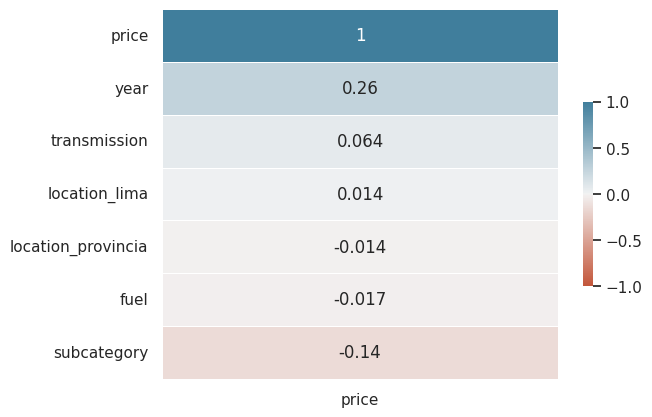

In [22]:
sns.heatmap(
    data=corr_charges.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

## PASO 6 - IDENTIFICAMOS VARIABLE X y Y , dividmos en train test

In [23]:
cols = corr_charges.index.tolist()
cols.remove('price')
cols

['fuel',
 'subcategory',
 'transmission',
 'location_lima',
 'location_provincia',
 'year']

In [24]:
X = data_transformed_df[cols].values
y = data_transformed_df['price'].values.reshape(-1,1)

In [25]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30,random_state=42)

# EVALUAR MODELOS

## 1 - IMPORTAMOS LIBRERIAS

In [26]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

## 2 - ESCALAMIENTO DE DATOS

# 3 - CREAMOS DICCIONARIO DE MODELOS

## 4 - CREAMOS BUCLE PARA PROBAR CADA MODELO DEL DICCIONARIO

# MOSTRAMOS RESULTADOS DE LOS MODELOS ENTRENADOS

# BUSCAMOS EL MEJOR MODELO

# GRAFICAMOS RESULTADOS